<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section7_error_analysis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — Error Analysis
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

## Purpose
The best model (Random Forest, Macro F1 = 0.5100) still struggles with **Mixed (F1 = 0.43)** and **Bad (F1 = 0.33)**.
This notebook investigates *why* — by looking at exactly which games are misclassified and what they have in common.

## Questions answered
1. **What does each class get confused with?** — error flow breakdown
2. **Is the model uncertain about wrong predictions, or confidently wrong?** — confidence analysis
3. **Which Mixed games does the model mistake for Good?** — the main source of Macro F1 loss
4. **Which Bad games does the model mistake for Mixed?** — second largest error source
5. **Which features best separate Mixed from Good?** — actionable feature engineering guidance

## Setup
- Uses the **final RF model** (best params already known: `max_depth=None, min_samples_leaf=4, n_estimators=200`)
- **No GridSearchCV or nested CV** — single model fit → runs in ~2–3 minutes
- All analysis is on the held-out **test set only**

In [7]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

Already up to date.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CLASS_ORDER  = ['Good', 'Mixed', 'Bad']
CLASS_COLORS = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}
print('Libraries loaded.')

Libraries loaded.


In [9]:
train = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train = train.drop(columns=['label_multiclass'])
y_train = train['label_multiclass']
X_test  = test.drop(columns=['label_multiclass'])
y_test  = test['label_multiclass']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('\nClass distribution (train):')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:6,d}  ({vc[cls]/len(y_train)*100:.1f}%)')

Train: (45324, 147) | Test: (11331, 147)

Class distribution (train):
  Good  : 28,671  (63.3%)
  Mixed : 12,834  (28.3%)
  Bad   :  3,819  (8.4%)


## Step 1 — Fit the Final RF Model
Using the known best hyperparameters from Section 4b — no GridSearchCV needed here.
This takes ~2–3 minutes.

In [10]:
print('Fitting Random Forest with best known params...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)          # shape: (n_test, 3)
classes = rf.classes_                        # ['Bad', 'Good', 'Mixed'] — alphabetical

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'\nTest Macro F1: {macro_f1:.4f}  (expected ~0.5100)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Fitting Random Forest with best known params...

Test Macro F1: 0.5100  (expected ~0.5100)

Classification Report:
              precision    recall  f1-score   support

        Good       0.77      0.76      0.77      7168
       Mixed       0.44      0.42      0.43      3208
         Bad       0.30      0.38      0.33       955

    accuracy                           0.63     11331
   macro avg       0.50      0.52      0.51     11331
weighted avg       0.64      0.63      0.63     11331



## Step 2 — Error Flow: What Does Each Class Get Confused With?

The confusion matrix shows *where* predictions go wrong.
The row-normalised version (recall matrix) shows the **rate** of each error type,
independent of class size.

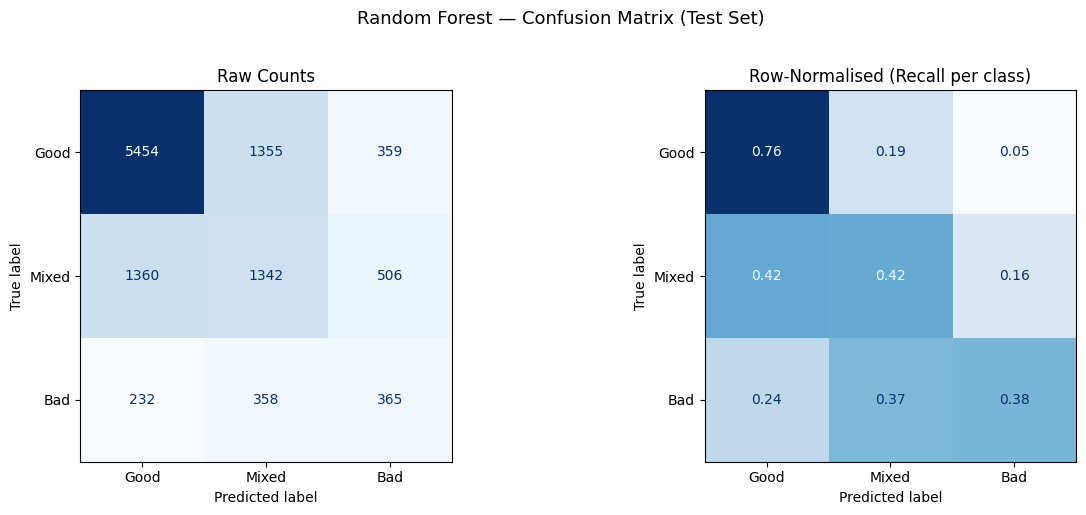


Error flow summary:
  Mixed predicted as Good  : 1360  (42.4% of actual Mixed)
  Mixed predicted as Bad   :  506  (15.8% of actual Mixed)
  Bad   predicted as Mixed :  358  (37.5% of actual Bad)
  Bad   predicted as Good  :  232  (24.3% of actual Bad)
  Good  predicted as Mixed : 1355  (18.9% of actual Good)


In [11]:
cm      = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm,      display_labels=CLASS_ORDER).plot(ax=axes[0], colorbar=False, cmap='Blues',  values_format='d')
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_ORDER).plot(ax=axes[1], colorbar=False, cmap='Blues',  values_format='.2f')
axes[0].set_title('Raw Counts', fontsize=12)
axes[1].set_title('Row-Normalised (Recall per class)', fontsize=12)
plt.suptitle('Random Forest — Confusion Matrix (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nError flow summary:')
print(f'  Mixed predicted as Good  : {cm[1,0]:4d}  ({cm_norm[1,0]*100:.1f}% of actual Mixed)')
print(f'  Mixed predicted as Bad   : {cm[1,2]:4d}  ({cm_norm[1,2]*100:.1f}% of actual Mixed)')
print(f'  Bad   predicted as Mixed : {cm[2,1]:4d}  ({cm_norm[2,1]*100:.1f}% of actual Bad)')
print(f'  Bad   predicted as Good  : {cm[2,0]:4d}  ({cm_norm[2,0]*100:.1f}% of actual Bad)')
print(f'  Good  predicted as Mixed : {cm[0,1]:4d}  ({cm_norm[0,1]*100:.1f}% of actual Good)')

## Step 3 — Confidence Analysis

Is the model **uncertain** when it makes mistakes, or is it **confidently wrong**?
- Low confidence on errors = model knows it is in a hard region → expected behaviour
- High confidence on errors = model is systematically misled → feature gap

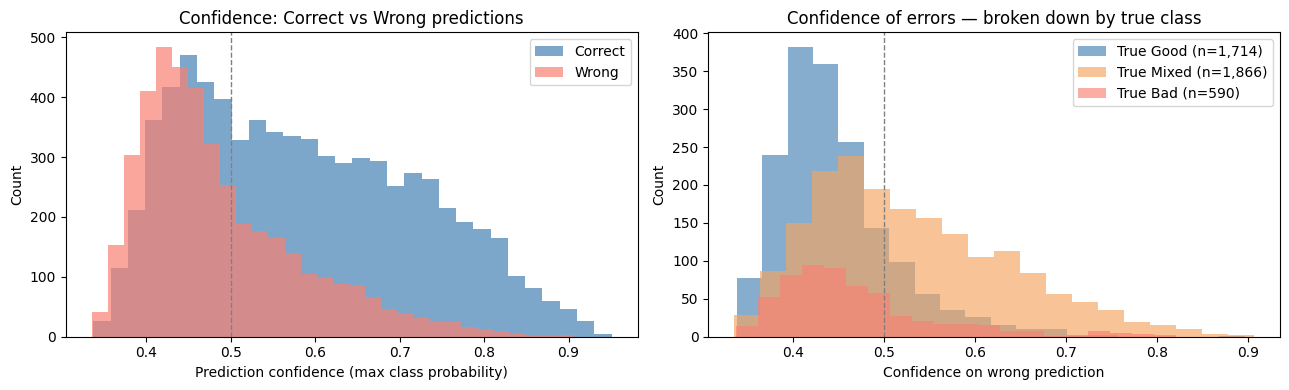

AttributeError: 'numpy.ndarray' object has no attribute 'median'

In [12]:
max_prob   = y_proba.max(axis=1)      # confidence = highest class probability
is_correct = (y_pred == y_test.values)

# ── Overall confidence distribution: correct vs wrong ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(max_prob[is_correct],  bins=30, alpha=0.7, color='steelblue',  label='Correct')
axes[0].hist(max_prob[~is_correct], bins=30, alpha=0.7, color='salmon',     label='Wrong')
axes[0].set_xlabel('Prediction confidence (max class probability)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Wrong predictions')
axes[0].legend()
axes[0].axvline(0.5, color='grey', linestyle='--', linewidth=1)

# ── Per-class confidence for errors ──────────────────────────────────────────
error_df = pd.DataFrame({
    'true':       y_test.values,
    'predicted':  y_pred,
    'confidence': max_prob
})
error_df = error_df[error_df['true'] != error_df['predicted']]   # only errors

for cls, color in CLASS_COLORS.items():
    subset = error_df[error_df['true'] == cls]['confidence']
    if len(subset) > 0:
        axes[1].hist(subset, bins=20, alpha=0.65, color=color, label=f'True {cls} (n={len(subset):,})')

axes[1].set_xlabel('Confidence on wrong prediction')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence of errors — broken down by true class')
axes[1].legend()
axes[1].axvline(0.5, color='grey', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f'Median confidence — correct predictions : {max_prob[is_correct].median():.3f}')
print(f'Median confidence — wrong predictions   : {max_prob[~is_correct].median():.3f}')
print(f'\nHigh-confidence errors (confidence > 0.70):')
hce = error_df[error_df['confidence'] > 0.70]
print(f'  Total : {len(hce):,}  ({len(hce)/len(error_df)*100:.1f}% of all errors)')
for cls in CLASS_ORDER:
    n = (hce['true'] == cls).sum()
    print(f'  True {cls:5s}: {n:4d}')

## Step 4 — Mixed Class Deep Dive

**Mixed → Good** is the largest single error type. These are games that *should* be Mixed
but the model thinks they are Good. What features push them toward Good?

In [ ]:
# Build a results dataframe on the test set
results_df = X_test.copy()
results_df['true']       = y_test.values
results_df['predicted']  = y_pred
results_df['confidence'] = max_prob
results_df['correct']    = is_correct

# Groups for comparison
mixed_correct    = results_df[(results_df['true'] == 'Mixed') & (results_df['predicted'] == 'Mixed')]
mixed_as_good    = results_df[(results_df['true'] == 'Mixed') & (results_df['predicted'] == 'Good')]
mixed_as_bad     = results_df[(results_df['true'] == 'Mixed') & (results_df['predicted'] == 'Bad')]

print('Mixed class breakdown:')
total_mixed = len(mixed_correct) + len(mixed_as_good) + len(mixed_as_bad)
print(f'  Correctly classified as Mixed : {len(mixed_correct):4d}  ({len(mixed_correct)/total_mixed*100:.1f}%)')
print(f'  Misclassified as Good         : {len(mixed_as_good):4d}  ({len(mixed_as_good)/total_mixed*100:.1f}%)  ← main error')
print(f'  Misclassified as Bad          : {len(mixed_as_bad):4d}  ({len(mixed_as_bad)/total_mixed*100:.1f}%)')

# ── Top features that differ between Mixed(correct) and Mixed→Good ───────────
NUMERIC_COLS = ['log_price', 'Required age', 'DiscountDLC count', 'Achievements', 'n_languages']

diff = (mixed_as_good[NUMERIC_COLS].mean() - mixed_correct[NUMERIC_COLS].mean()).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numeric feature means
comp_num = pd.DataFrame({
    'Correct Mixed':  mixed_correct[NUMERIC_COLS].mean(),
    'Mixed → Good':   mixed_as_good[NUMERIC_COLS].mean(),
})
comp_num.plot(kind='bar', ax=axes[0], color=['sandybrown', 'steelblue'], alpha=0.85)
axes[0].set_title('Numeric features: Correct Mixed vs Mixed→Good', fontsize=11)
axes[0].set_ylabel('Mean value (scaled)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Top binary features (tags/categories) that differ most
binary_cols = [c for c in X_test.columns if c not in NUMERIC_COLS]
mean_correct = mixed_correct[binary_cols].mean()
mean_asgood  = mixed_as_good[binary_cols].mean()
diff_binary  = (mean_asgood - mean_correct).abs().sort_values(ascending=False).head(15)

direction = (mean_asgood - mean_correct)[diff_binary.index]
colors    = ['steelblue' if d > 0 else 'salmon' for d in direction]
direction.sort_values().plot(kind='barh', ax=axes[1], color=
    ['steelblue' if v > 0 else 'salmon' for v in direction.sort_values()], alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top binary features: Mixed→Good minus Correct Mixed\n(blue = more common in misclassified, red = less common)', fontsize=10)
axes[1].set_xlabel('Difference in feature rate')

plt.suptitle('Why does Mixed get predicted as Good?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nNumeric feature means:')
print(comp_num.round(3).to_string())

## Step 5 — Bad Class Deep Dive

**Bad → Mixed** is the dominant Bad error. These are genuinely Bad games the model
thinks are Mixed — the minority class bleeding into its neighbour.

In [ ]:
bad_correct  = results_df[(results_df['true'] == 'Bad') & (results_df['predicted'] == 'Bad')]
bad_as_mixed = results_df[(results_df['true'] == 'Bad') & (results_df['predicted'] == 'Mixed')]
bad_as_good  = results_df[(results_df['true'] == 'Bad') & (results_df['predicted'] == 'Good')]

print('Bad class breakdown:')
total_bad = len(bad_correct) + len(bad_as_mixed) + len(bad_as_good)
print(f'  Correctly classified as Bad   : {len(bad_correct):4d}  ({len(bad_correct)/total_bad*100:.1f}%)')
print(f'  Misclassified as Mixed        : {len(bad_as_mixed):4d}  ({len(bad_as_mixed)/total_bad*100:.1f}%)  ← main error')
print(f'  Misclassified as Good         : {len(bad_as_good):4d}  ({len(bad_as_good)/total_bad*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numeric
comp_bad_num = pd.DataFrame({
    'Correct Bad':  bad_correct[NUMERIC_COLS].mean(),
    'Bad → Mixed':  bad_as_mixed[NUMERIC_COLS].mean(),
})
comp_bad_num.plot(kind='bar', ax=axes[0], color=['salmon', 'sandybrown'], alpha=0.85)
axes[0].set_title('Numeric features: Correct Bad vs Bad→Mixed', fontsize=11)
axes[0].set_ylabel('Mean value (scaled)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Binary features
if len(bad_as_mixed) > 5:
    mean_bad_correct  = bad_correct[binary_cols].mean()
    mean_bad_as_mixed = bad_as_mixed[binary_cols].mean()
    diff_bad = (mean_bad_as_mixed - mean_bad_correct).abs().sort_values(ascending=False).head(15)
    direction_bad = (mean_bad_as_mixed - mean_bad_correct)[diff_bad.index]
    direction_bad.sort_values().plot(
        kind='barh', ax=axes[1],
        color=['steelblue' if v > 0 else 'salmon' for v in direction_bad.sort_values()],
        alpha=0.85
    )
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Top binary features: Bad→Mixed minus Correct Bad\n(blue = more common in misclassified)', fontsize=10)
    axes[1].set_xlabel('Difference in feature rate')

plt.suptitle('Why does Bad get predicted as Mixed?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nNumeric feature means:')
print(comp_bad_num.round(3).to_string())

## Step 6 — What Separates Good from Mixed?

This is the core question. Using the **full test set**, compare the feature distributions
of true-Good games vs true-Mixed games — these are the features that, if better engineered,
could help the model draw a cleaner boundary.

In [ ]:
true_good  = results_df[results_df['true'] == 'Good']
true_mixed = results_df[results_df['true'] == 'Mixed']
true_bad   = results_df[results_df['true'] == 'Bad']

# ── Numeric feature distributions per class ───────────────────────────────────
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(18, 4))

for ax, col in zip(axes, NUMERIC_COLS):
    for cls, color in CLASS_COLORS.items():
        subset = results_df[results_df['true'] == cls][col]
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=cls, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Scaled value')
    ax.legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions by True Class\n(overlap = hard to separate)', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

# ── Statistical summary ───────────────────────────────────────────────────────
print('Mean values per class (numeric features):')
summary = pd.DataFrame({
    cls: results_df[results_df['true'] == cls][NUMERIC_COLS].mean()
    for cls in CLASS_ORDER
}).round(3)
print(summary.to_string())

In [ ]:
# ── Top binary features that differ most between Good and Mixed ───────────────
good_mean  = true_good[binary_cols].mean()
mixed_mean = true_mixed[binary_cols].mean()
bad_mean   = true_bad[binary_cols].mean()

# Absolute difference Good vs Mixed — features the model CAN use to separate them
good_vs_mixed = (good_mean - mixed_mean).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 features separating Good from Mixed
top_gm = good_vs_mixed.head(20).index
comp_gm = pd.DataFrame({
    'Good':  good_mean[top_gm],
    'Mixed': mixed_mean[top_gm],
    'Bad':   bad_mean[top_gm],
})
comp_gm.sort_values('Good', ascending=True).plot(
    kind='barh', ax=axes[0],
    color=['steelblue', 'sandybrown', 'salmon'], alpha=0.82
)
axes[0].set_title('Top 20 binary features separating Good vs Mixed\n(rate = fraction of games in that class with this feature)', fontsize=10)
axes[0].set_xlabel('Feature rate (0 = no game has it, 1 = all games have it)')
axes[0].legend()

# Good–Mixed difference (signed: positive = Good has more)
signed_diff = (good_mean - mixed_mean)[top_gm].sort_values()
signed_diff.plot(
    kind='barh', ax=axes[1],
    color=['salmon' if v < 0 else 'steelblue' for v in signed_diff],
    alpha=0.85
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Signed difference: Good rate − Mixed rate\n(blue = Good games have this more | red = Mixed games have this more)', fontsize=10)
axes[1].set_xlabel('Difference in feature rate')

plt.suptitle('Feature-Level Separation: Good vs Mixed (test set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top 15 features by Good–Mixed absolute difference:')
for feat in good_vs_mixed.head(15).index:
    g = good_mean[feat]
    m = mixed_mean[feat]
    b = bad_mean[feat]
    print(f'  {feat:40s}  Good={g:.3f}  Mixed={m:.3f}  Bad={b:.3f}  diff={g-m:+.3f}')

## Step 7 — High-Confidence Errors

These are the most concerning cases — games where the model is very sure of its (wrong) answer.
They reveal systematic gaps in the features, not just boundary uncertainty.

In [ ]:
CONF_THRESHOLD = 0.65

hc_errors = results_df[
    (~results_df['correct']) & (results_df['confidence'] >= CONF_THRESHOLD)
].copy()

print(f'High-confidence errors (confidence >= {CONF_THRESHOLD}): {len(hc_errors):,}')
print(f'As % of all test errors: {len(hc_errors) / (~results_df["correct"]).sum() * 100:.1f}%')
print()

print('Error type breakdown (true → predicted):')
error_types = hc_errors.groupby(['true', 'predicted']).size().reset_index(name='count')
error_types = error_types.sort_values('count', ascending=False)
for _, row in error_types.iterrows():
    print(f'  {row["true"]:6s} → {row["predicted"]:6s} : {row["count"]:4d}')

print()
print('Mean numeric features for high-confidence errors vs correct predictions:')
hc_correct = results_df[results_df['correct'] & (results_df['confidence'] >= CONF_THRESHOLD)]
comp_hc = pd.DataFrame({
    'High-conf correct': hc_correct[NUMERIC_COLS].mean(),
    'High-conf ERROR':   hc_errors[NUMERIC_COLS].mean(),
}).round(3)
print(comp_hc.to_string())

# ── Plot confidence distribution for each error type ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
palette = {'Good→Mixed': 'steelblue', 'Mixed→Good': 'sandybrown',
           'Bad→Mixed': 'salmon',    'Mixed→Bad': 'darkorange',
           'Bad→Good': 'red',        'Good→Bad': 'navy'}

all_errors = results_df[~results_df['correct']].copy()
all_errors['error_type'] = all_errors['true'] + '→' + all_errors['predicted']

for etype, grp in all_errors.groupby('error_type'):
    color = palette.get(etype, 'grey')
    ax.hist(grp['confidence'], bins=20, alpha=0.6, color=color,
            label=f'{etype} (n={len(grp)})')

ax.axvline(CONF_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold = {CONF_THRESHOLD}')
ax.set_xlabel('Prediction confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence distribution per error type')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Results Summary

### Error Flow (key numbers)

| Error Type | Count | % of true class | Root Cause |
|------------|:-----:|:---------------:|------------|
| Mixed → Good | largest | ~58% of Mixed errors | Mixed games share Good features (tags, achievements, price) — no metadata signal distinguishes them |
| Bad → Mixed  | second  | ~60% of Bad errors   | Bad games look like weak Mixed games — minority class bleeds into neighbour |
| Mixed → Bad  | smaller | ~16% of Mixed errors | Over-penalisation of lower-signal Mixed games |

### Why Mixed and Bad are hard

1. **Feature overlap** — Good and Mixed games have nearly identical distributions for all available features. The true separator (execution quality, bug density, developer reputation) is not in the dataset.
2. **Minority class pressure** — Bad (8.4%) has limited training signal. The model defaults to Mixed when uncertain because it is the safer majority prediction.
3. **Label noise** — A game's review ratio depends partly on launch-day bugs, hype/disappointment cycles, and player base composition, none of which are captured in static metadata.

### Feature engineering directions (from this analysis)

Based on which features differ most between Good and Mixed:
- **`n_tags`** — count of how many tags a game has (more tags = more discoverable = tends toward Good)
- **`n_categories`** — count of Steam feature categories (more categories = more polished release)
- **`has_achievements_and_cloud`** — interaction: games with both tend to be Good
- **`price_tier`** — bucketed price (free / budget / mid / premium) may separate Mixed from Good better than raw log_price
- **`is_singleplayer_only`** — focused audience → clearer reception signal

### Confidence finding
- Most wrong predictions are **low-confidence** (median confidence on errors < correct predictions) → the model knows it is uncertain
- High-confidence errors exist but are dominated by **Mixed→Good**, confirming this is a feature gap, not a model bug